<a href="https://colab.research.google.com/github/le-aditya/Q--Hack/blob/main/Level1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=5ef4ff6cd31835cb448ed138e193846d571f3af99124606704feb187bc5e8906
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
  4-BIT RIPPLE CARRY ADDER
Input A : 0 1 0 1  =  5
Input B : 0 0 1 1  =  3
Sum     : 1 0 0 0  =  8
Carry   : 0

5 + 3 = 8 


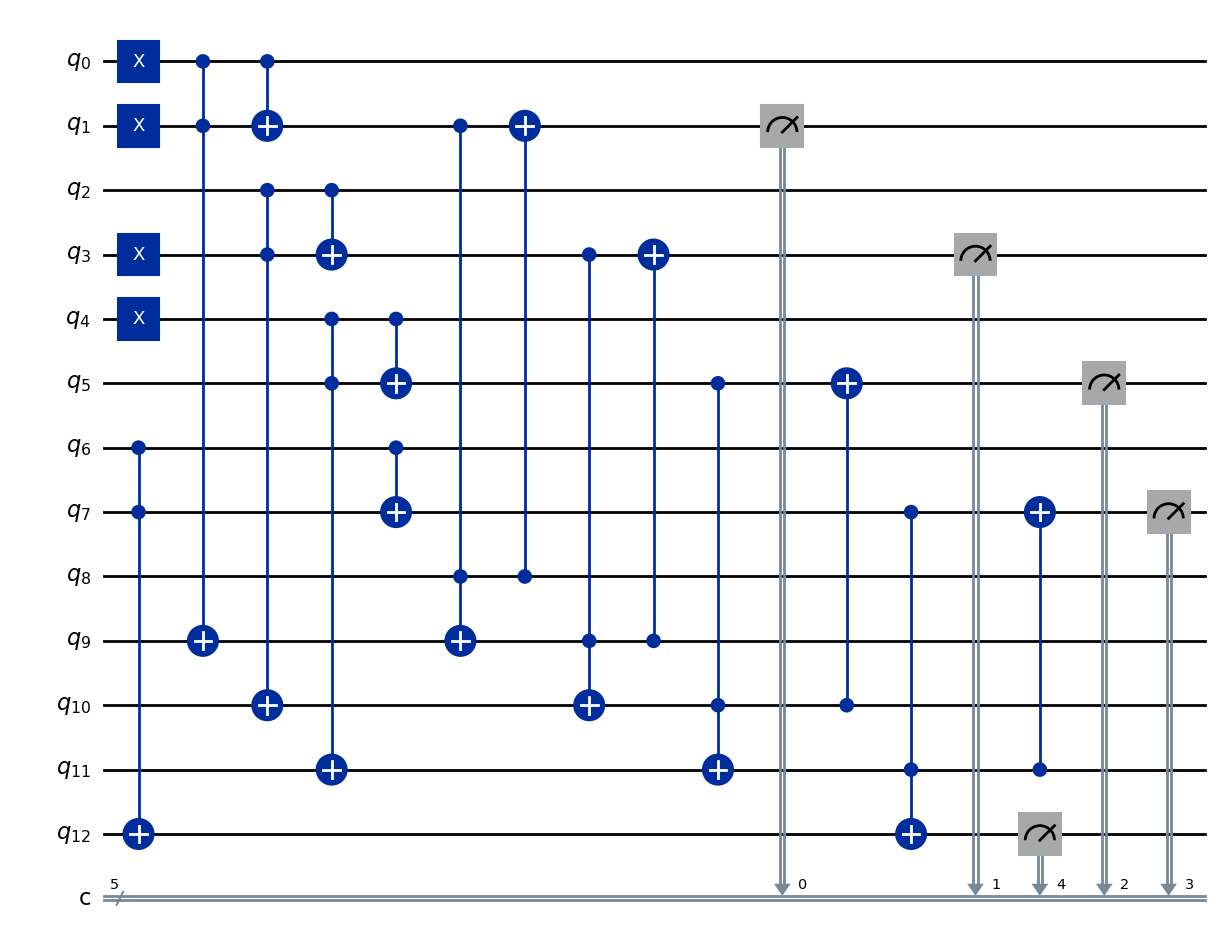

In [1]:
%pip install qiskit qiskit-aer matplotlib pylatexenc
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer

qc = QuantumCircuit(13, 5)

A3, A2, A1, A0 = 0, 1, 0, 1   # 5
B3, B2, B1, B0 = 0, 0, 1, 1   # 3
Cin = 0
if A0 == 1: qc.x(0)
if B0 == 1: qc.x(1)
if A1 == 1: qc.x(2)
if B1 == 1: qc.x(3)
if A2 == 1: qc.x(4)
if B2 == 1: qc.x(5)
if A3 == 1: qc.x(6)
if B3 == 1: qc.x(7)
if Cin == 1: qc.x(8)

qc.ccx(0, 1, 9)
qc.cx(0, 1)
qc.ccx(8, 1, 9)
qc.cx(8, 1)

qc.ccx(2, 3, 10)
qc.cx(2, 3)
qc.ccx(9, 3, 10)
qc.cx(9, 3)

qc.ccx(4, 5, 11)
qc.cx(4, 5)
qc.ccx(10, 5, 11)
qc.cx(10, 5)

qc.ccx(6, 7, 12)
qc.cx(6, 7)
qc.ccx(11, 7, 12)
qc.cx(11, 7)

qc.measure(1,  0)   # S0
qc.measure(3,  1)   # S1
qc.measure(5,  2)   # S2
qc.measure(7,  3)   # S3
qc.measure(12, 4)   # Carry

simulator = Aer.get_backend('aer_simulator')
compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1024).result()

counts = result.get_counts()
output = list(counts.keys())[0][::-1]  # reverse bit order

S0    = output[0]
S1    = output[1]
S2    = output[2]
S3    = output[3]
Carry = output[4]

# Calculate decimal values
A_decimal = A3*8 + A2*4 + A1*2 + A0
B_decimal = B3*8 + B2*4 + B1*2 + B0
Sum_decimal = int(S3)*8 + int(S2)*4 + int(S1)*2 + int(S0)

print("=" * 35)
print("  4-BIT RIPPLE CARRY ADDER")
print("=" * 35)
print(f"Input A : {A3} {A2} {A1} {A0}  =  {A_decimal}")
print(f"Input B : {B3} {B2} {B1} {B0}  =  {B_decimal}")
print(f"Sum     : {S3} {S2} {S1} {S0}  =  {Sum_decimal}")
print(f"Carry   : {Carry}")
print(f"\n{A_decimal} + {B_decimal} = {Sum_decimal} ")
print("=" * 35)

qc.draw('mpl')
